In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
path_to_dataset = "../../public_data"

# Confidence Estimation

In [3]:
import pathlib
import cdmetadl

PROJECT_DIR = pathlib.Path(cdmetadl.__file__).parent.parent

In [4]:
import pathlib

import cdmetadl.helpers.general_helpers
import cdmetadl.dataset

dataset_path = pathlib.Path(path_to_dataset)
dataset_info_dict = cdmetadl.helpers.general_helpers.check_datasets(dataset_path, ["AWA"])

dataset = cdmetadl.dataset.ImageDataset("-", dataset_info_dict["AWA"])

In [5]:
import cdmetadl.samplers

n_way_sampler = cdmetadl.samplers.ValueSampler(value=5)
k_shot_sampler = cdmetadl.samplers.ValueSampler(value=4)

task = dataset.generate_task(n_way_sampler, k_shot_sampler, query_size=4)

In [6]:
import cdmetadl.helpers.general_helpers

model_module = cdmetadl.helpers.general_helpers.load_module_from_path(PROJECT_DIR / "baselines/finetuning/model.py")


## Pseudo Confidence Estimation

[0.3832766, 0.2538034915924072, 0.42058253, 0.3772455, 0.31478413939476013]


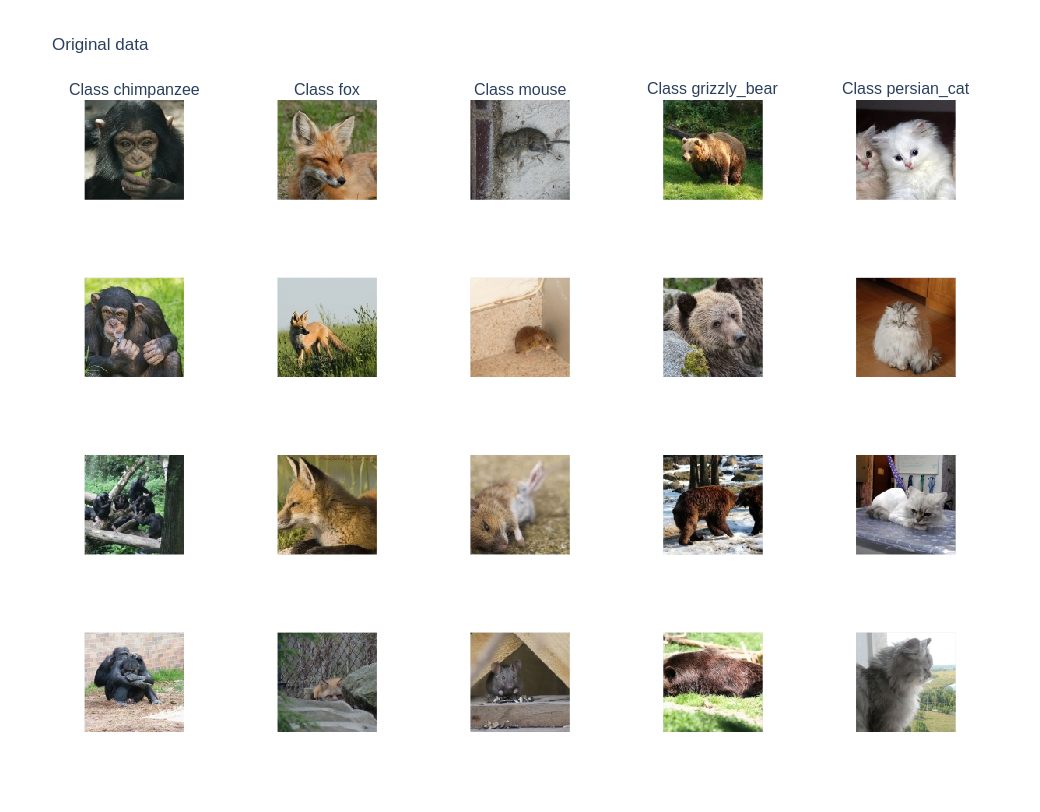

In [7]:
import cdmetadl.confidence
import cdmetadl.notebooks.helpers

learner = model_module.MyLearner()
learner.load("../../output/final/training/dropout_20_k_5/finetuning/cross-domain/model")

confidence_estimator = cdmetadl.confidence.PseudoConfidenceEstimator()
_, confidence_scores = confidence_estimator.estimate(learner, task.support_set)
print(confidence_scores)

fig = cdmetadl.notebooks.helpers.show_images_grid_plotly(task.support_set, True)

## Monte Carlo Dropout Confidence Estimation

In [8]:
import cdmetadl.confidence
import cdmetadl.notebooks.helpers
confidence_estimator = cdmetadl.confidence.MCDropoutConfidenceEstimator(num_samples=1000)

100%|██████████| 1000/1000 [00:02<00:00, 342.33it/s]


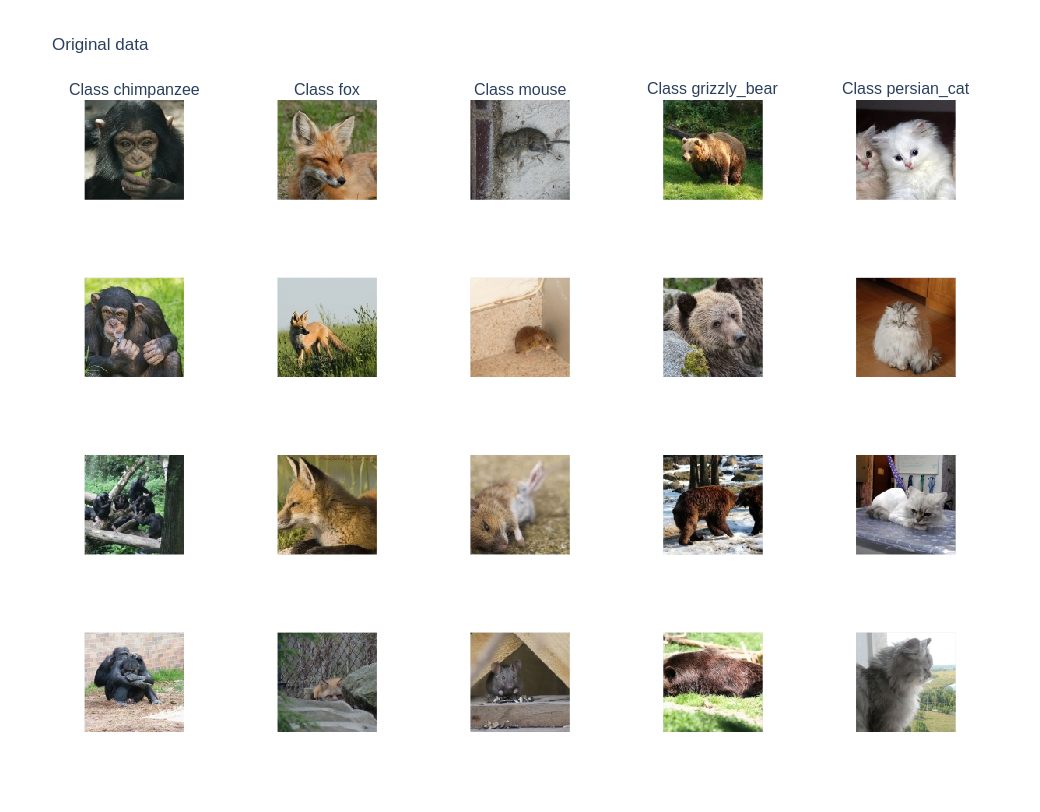

[9.0415497e-06 2.3228684e-05 4.0529387e-05 2.0647996e-05 2.7907998e-05]


In [9]:
learner = model_module.MyLearner()
learner.load("../../output/final/training/dropout_20_k_5/finetuning/cross-domain/model")
learner.T = 2_000
_, confidence_scores = confidence_estimator.estimate(learner, task.support_set)

fig = cdmetadl.notebooks.helpers.show_images_grid_plotly(task.support_set, True)

print(confidence_scores)

In [10]:
from tqdm import tqdm
import numpy as np
import pandas as pd

samples_conf_scores = 10

conf_scores = []
for T in [10, 100, 1000, 2000]:
    print(f"Test with T={T}")
    conf_scores = []

    for sample in tqdm(range(samples_conf_scores)):
        learner = model_module.MyLearner()
        learner.load("../../output/final/training/dropout_20_k_5/finetuning/cross-domain/model")
        learner.T = T
        conf_scores.append(confidence_estimator.estimate(learner, task.support_set)[1])
    
    conf_scores = np.array(conf_scores)
    avg_correlation = (sum(np.corrcoef(conf_scores).flatten()) - samples_conf_scores)/(samples_conf_scores**2 - samples_conf_scores)

    print(f"correlation for T={T}: {round(avg_correlation, 5)}, given just np.mean(class_predictions.var(axis=0), axis=0)")
    print(pd.Series(conf_scores.argmax(axis=1)).value_counts())
    print(pd.Series(conf_scores.argmin(axis=1)).value_counts())
    print(pd.DataFrame(conf_scores).rank(axis=1).mean())

Test with T=10


  0%|          | 0/10 [00:00<?, ?it/s]

 40%|████      | 4/10 [00:22<00:34,  5.73s/it]


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/workstation/Dokumente/GitHub/Confidence-based-generative-data-Augmentation-for-Meta-Learning/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_60016/3984439390.py", line 17, in <module>
    conf_scores.append(confidence_estimator.estimate(learner, task.support_set)[1])
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/workstation/Dokumente/GitHub/Confidence-based-generative-data-Augmentation-for-Meta-Learning/cdmetadl/confidence/mc_dropout_estimator.py", line 43, in estimate
    predictor = learner.fit(data_set)
                ^^^^^^^^^^^^^^^^^^^^^
  File "/home/workstation/Dokumente/GitHub/Confidence-based-generative-data-Augmentation-for-Meta-Learning/baselines/finetuning/model.py", line 404, in fit
    optimize_linear(self.learner, optimizer, X_batch, y_batch)
  File "/hom